# Недообучение и переобучение

## Каримова Идэль ИД24-3

## Классная работа

In [1]:
pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### Диагностика моделей классификации

In [3]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, n_repeated=0,
                           class_sep=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=3)

In [4]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

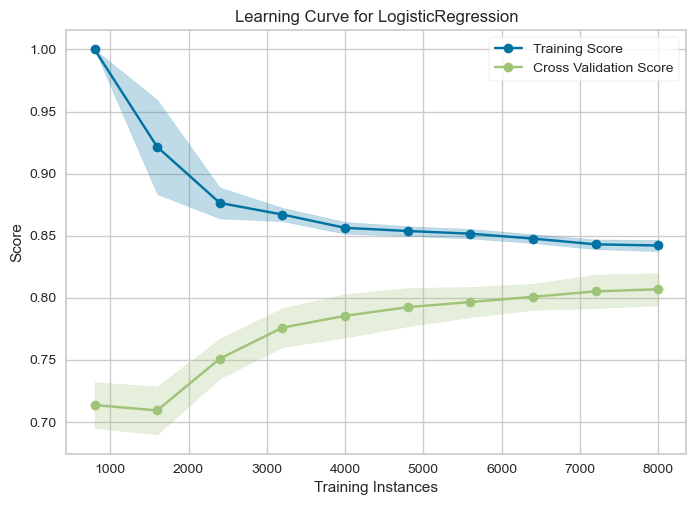

In [5]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y).show()

In [6]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


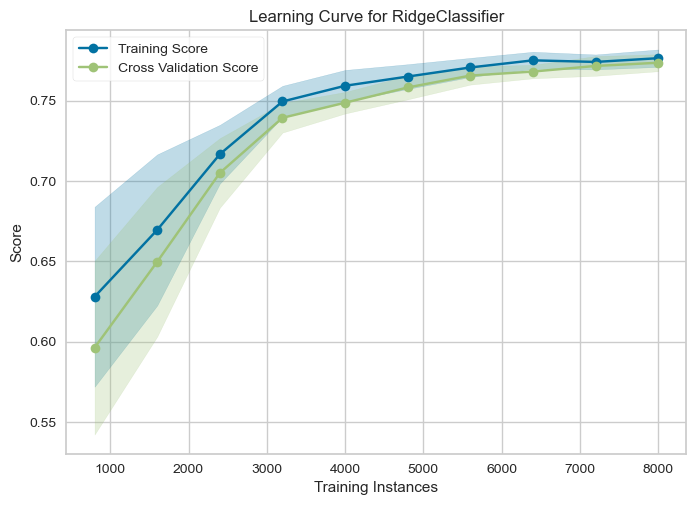

In [7]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

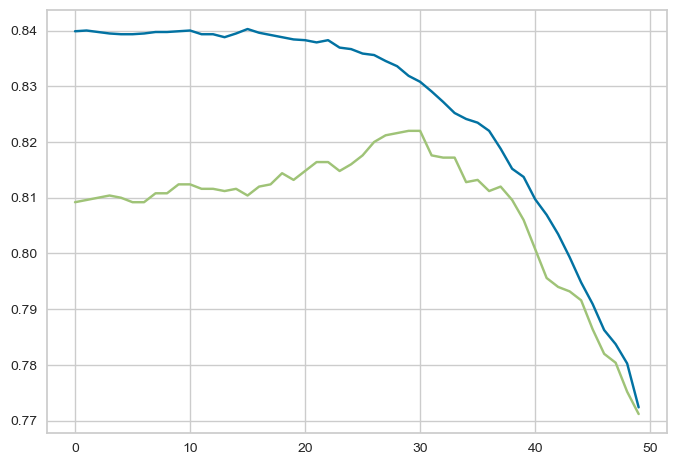

In [8]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []

for i in np.logspace(2, 6, 50):
  ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains)
plt.plot(tests)

In [9]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


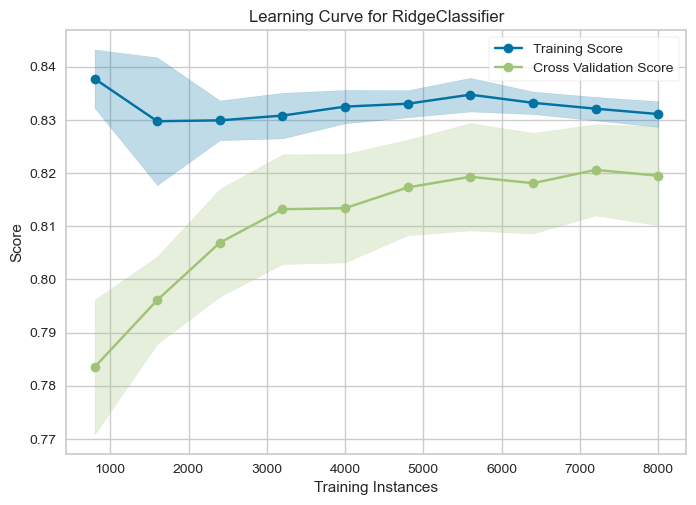

In [10]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

### Диагностика моделей регрессии

In [11]:
from numpy import genfromtxt
dataset = genfromtxt('https://raw.githubusercontent.com/datatweets/tutorials/refs/heads/main/misc/boston_housing.csv', delimiter=',')
X = dataset[:,:-1]
y = dataset[:,-1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [12]:
X = dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [14]:
X_train.shape, y_train.shape

((379, 105), (379,))

In [15]:
from sklearn.linear_model import LinearRegression, Ridge

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 1.0000
Test score: 1.0000


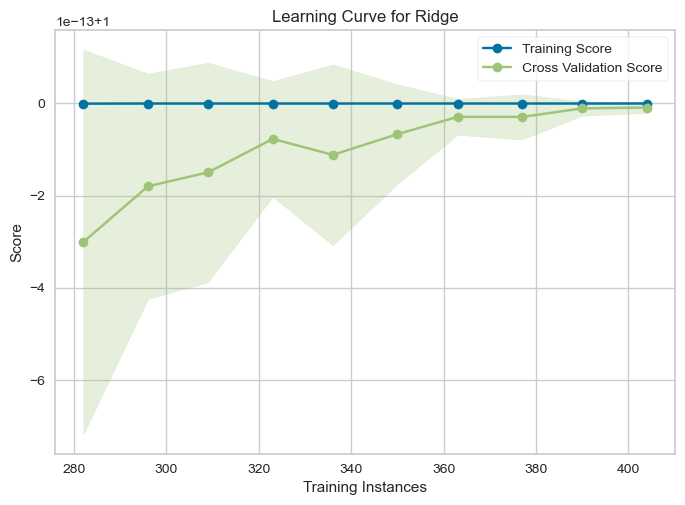

In [17]:
from yellowbrick.model_selection import LearningCurve
visualizer = LearningCurve(
    Ridge(alpha=0.0001), scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X, y) .show()

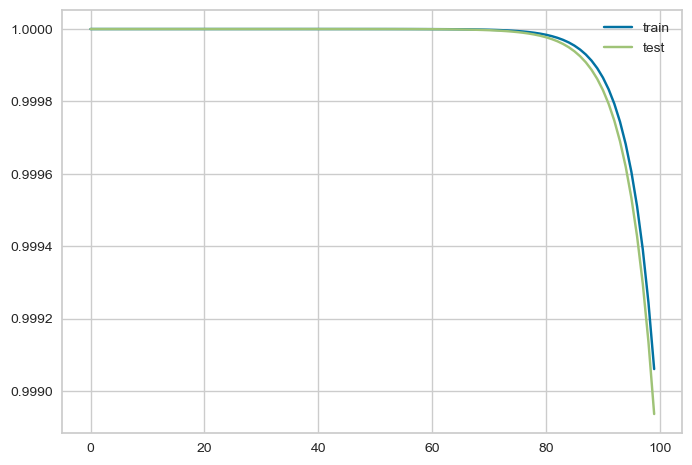

In [18]:
from sklearn.linear_model import Ridge
trains = []
tests = []

for i in np.logspace(-2, 3, 100):
  ridge = Ridge(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [19]:
lr = Ridge(alpha=0.18).fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 1.00
Linear Regression-Test set score: 1.00


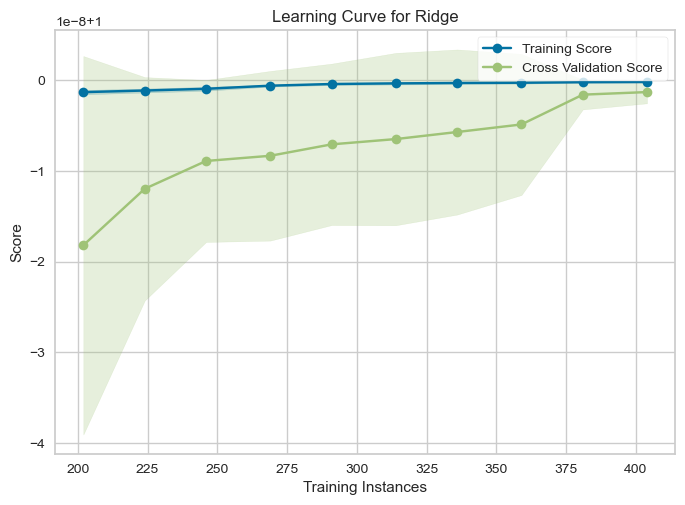

In [20]:
visualizer = LearningCurve(
    Ridge(alpha=0.18), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

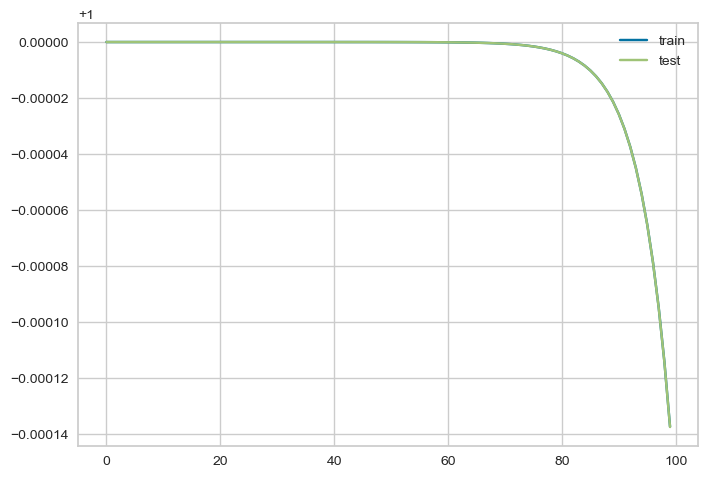

In [21]:
from sklearn.linear_model import Lasso
trains = []
tests = []

for i in np.logspace(-4, 0, 100):
  ridge = Lasso(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

### Диагностика на реальных данных

In [22]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv',nrows=200)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.5500


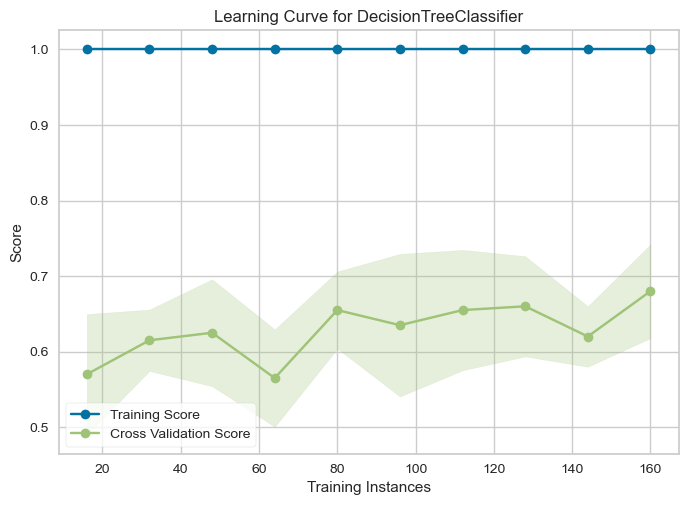

In [25]:
visualizer = LearningCurve(
     DecisionTreeClassifier(random_state=1), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y).show()

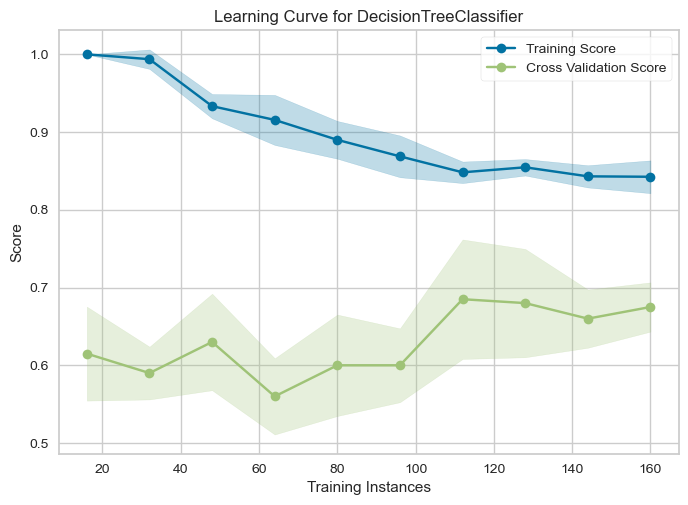

In [26]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

In [27]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273


### Диагностика недообучения

In [28]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name='delta_ailerons', parser="auto")
data.data.shape

(7129, 5)

In [29]:
X = pd.get_dummies(data.data)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


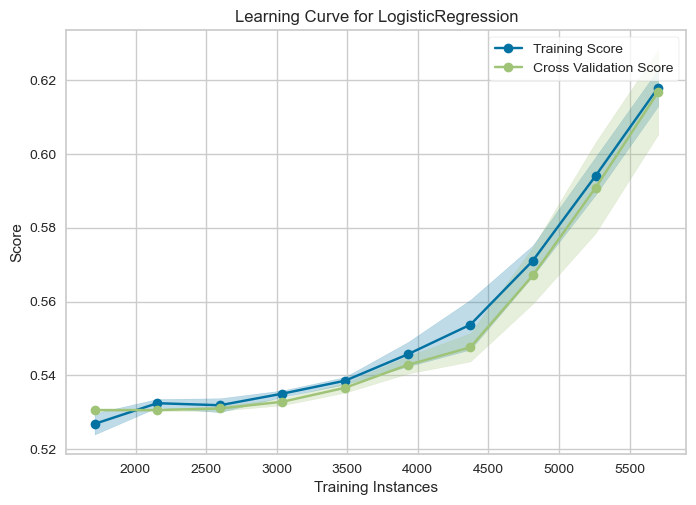

In [31]:
visualizer = LearningCurve(
    LogisticRegression(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show()

In [32]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier().fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9388
Test score = 0.9397


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

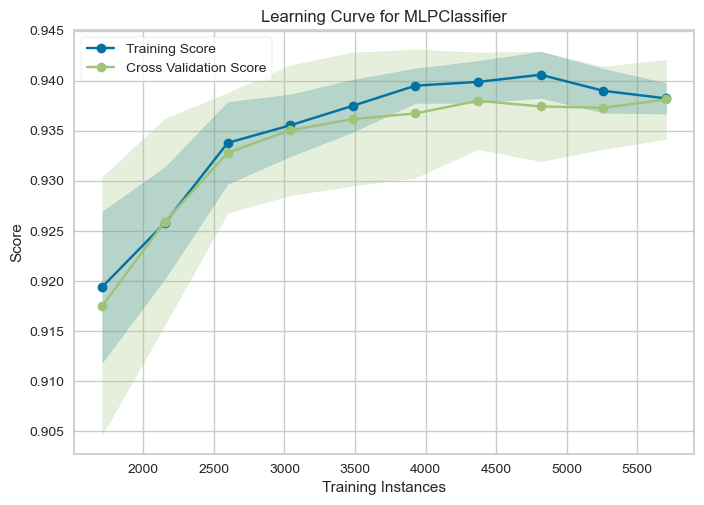

In [33]:
visualizer = LearningCurve(
    MLPClassifier(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show()

In [34]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import PolynomialFeatures

model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


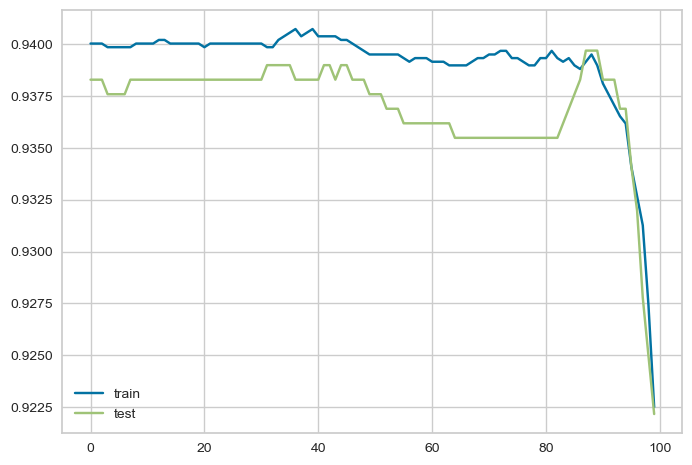

In [35]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(-7, 0, 100):
  ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
  trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
  tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

### Домашняя работа

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from numpy import genfromtxt
from sklearn.linear_model import Lasso
from sklearn.datasets import fetch_openml

1. Повторите диагностику модели классификации синтетических данных с использованием других метрик эффективности — точности, полноты и F1. Как изменились результаты?

In [37]:
X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, random_state=42)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=3)


In [39]:
model = LogisticRegression().fit(X_train, y_train)

In [40]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [41]:
print("Precision:", precision_score(y_train, train_pred))
print("Recall:", recall_score(y_train, train_pred))
print("F1:", f1_score(y_train, train_pred))

Precision: 0.8336825563122053
Recall: 0.8515248796147673
F1: 0.8425092641609317


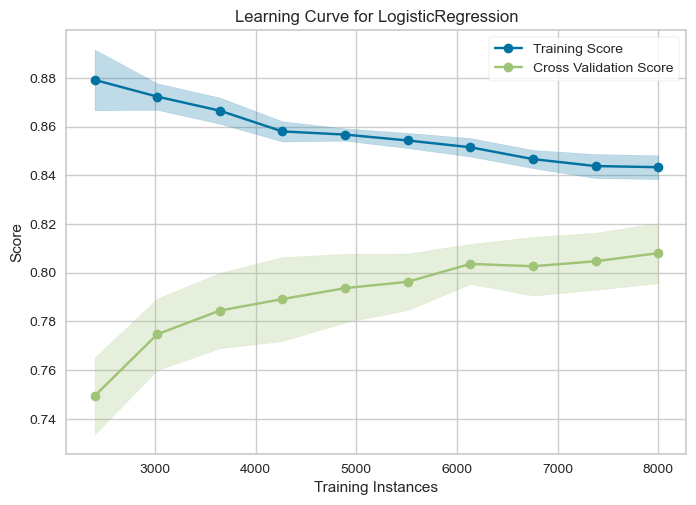

<Axes: title={'center': 'Learning Curve for LogisticRegression'}, xlabel='Training Instances', ylabel='Score'>

In [42]:
visualizer = LearningCurve(
    LogisticRegression(max_iter=1000),
    scoring='f1',
    train_sizes=np.linspace(0.3, 1.0, 10)
)

visualizer.fit(X, y)
visualizer.show()

2. Повторите диагностику модели регрессии с использованием других типов моделей:
метод опорных векторов (исследуйте влияние параметра С на недообучение и переобучение)
метод ближайших соседей (исследуйте влияние количества соседей)
метод решающих деревьев (гиперпараметры по вашему выбору)

In [43]:
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

X, y = make_regression(n_samples=5000, n_features=20, noise=10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

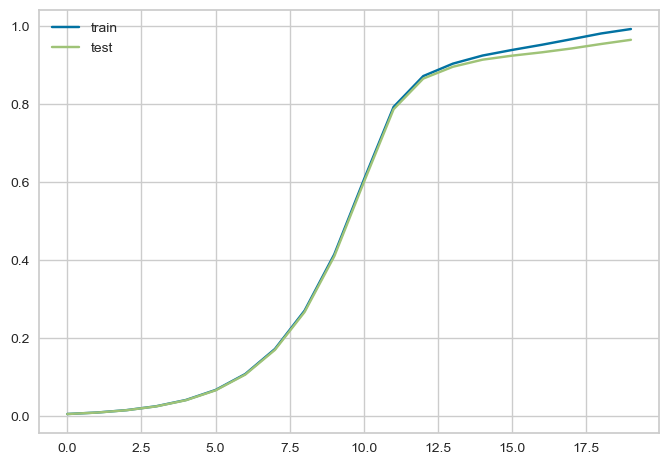

In [45]:
from sklearn.svm import SVR

trains = []
tests = []

for c in np.logspace(-2, 2, 20):

    model = SVR(C=c)
    model.fit(X_train, y_train)

    trains.append(r2_score(y_train, model.predict(X_train)))
    tests.append(r2_score(y_test, model.predict(X_test)))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()


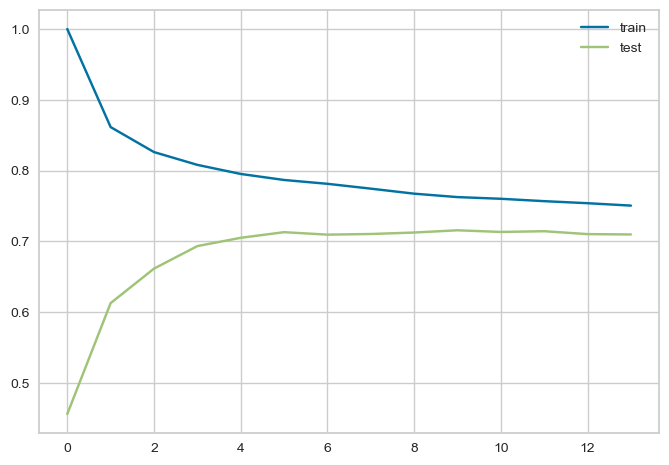

In [46]:
from sklearn.neighbors import KNeighborsRegressor

trains = []
tests = []

for k in range(1, 15):

    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

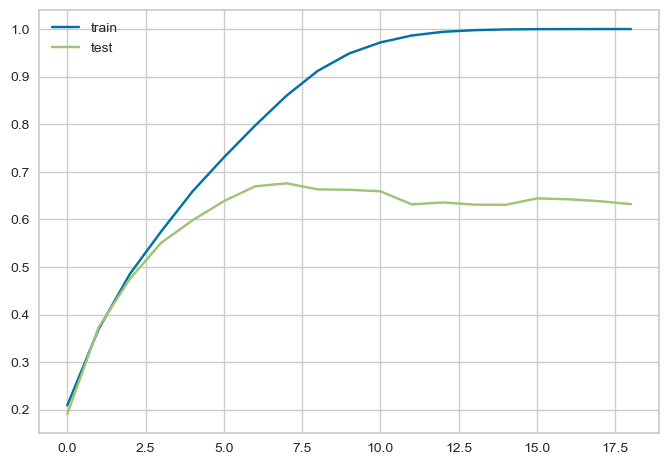

In [47]:
from sklearn.tree import DecisionTreeRegressor

trains = []
tests = []

for depth in range(1, 20):

    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train, y_train)

    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

 3. Дополните анализ датасета «Бостон» исследованием модели лассо — постройте кривые обучения для переобученной, недообученной и качественной модели, найдите оптимальное значение параметра регуляризации в модели лассо.

In [48]:
dataset = genfromtxt('https://raw.githubusercontent.com/datatweets/tutorials/refs/heads/main/misc/boston_housing.csv', delimiter=',')

In [49]:
X = dataset[:,:-1]
y = dataset[:,-1]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=0)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.440e+02, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.464e+02, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.480e+02, toleranc

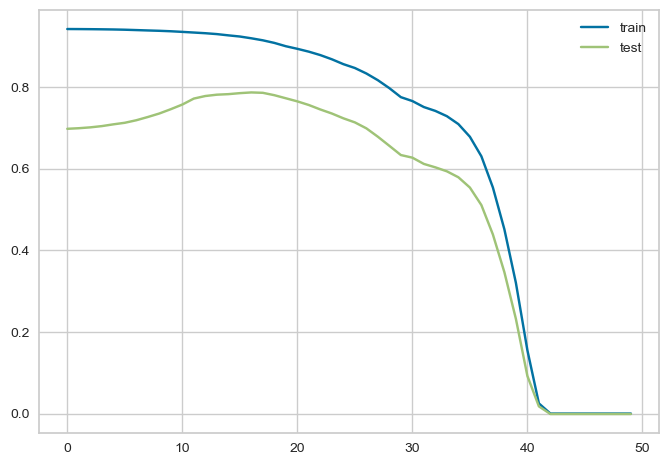

In [51]:
trains = []
tests = []

for a in np.logspace(-4, 1, 50):

    model = Lasso(alpha=a)
    model.fit(X_train, y_train)

    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

4. В одном из двух первых примеров используйте модель ElasticNet и исследуйте влияние сразу двух параметров регуляризации на эффективность модели.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.443e+03, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.417e+03, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.083e+03, toleranc

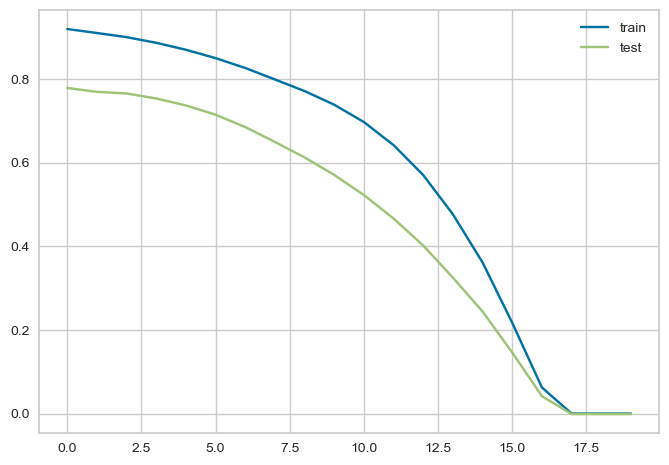

In [52]:
from sklearn.linear_model import ElasticNet

trains = []
tests = []

for a in np.logspace(-3, 1, 20):

    model = ElasticNet(alpha=a, l1_ratio=0.5)
    model.fit(X_train, y_train)

    trains.append(model.score(X_train, y_train))
    tests.append(model.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

5. Дополните анализ дерева решений из третьего примера: постройте кривые регуляризации для полного датасета, найдите оптимальную глубину дерева и оцените качество такой модели на всем датасете. Повторите этот анализ, используя в качестве метрики эффективности F1.

In [53]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')

In [54]:
y = df["Outcome"]
X = df.drop("Outcome", axis=1)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

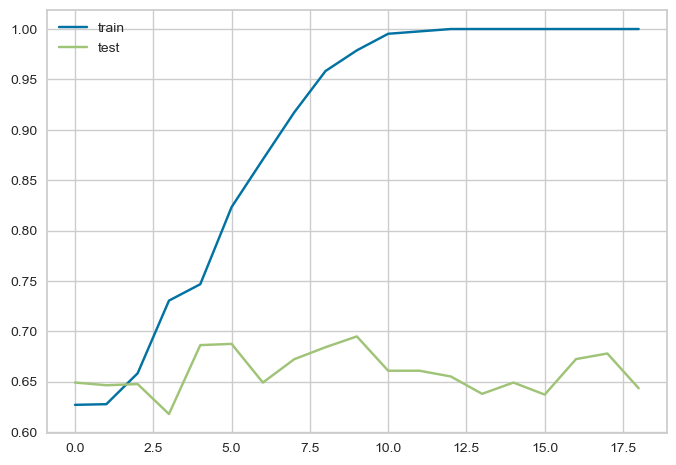

In [56]:
trains = []
tests = []

for depth in range(1, 20):

    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    trains.append(f1_score(y_train, model.predict(X_train)))
    tests.append(f1_score(y_test, model.predict(X_test)))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

6. Повторите анализ на других реальных наборах данных из репозитория OpenML:
фонема
аутентификация банкноты
дельта_элероны
маммография
электричество
mozilla4
кропт
детский сад
вулканы-b3

In [57]:
datasets = [
"phoneme",
"banknote-authentication",
"delta_ailerons",
"mammography",
"electricity",
"mozilla4",
"kropt",
"nursery",
"volcanoes-b3"
]

In [58]:
for name in datasets:

    data = fetch_openml(name=name, parser="auto")

    X = pd.get_dummies(data.data)
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0)

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    print(name)
    print("train:", model.score(X_train, y_train))
    print("test:", model.score(X_test, y_test))
    print()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:322: UserWarning: Multiple active versions of the dataset matching the name phoneme exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1489
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43973

  warn(warning_msg)


phoneme
train: 0.7543372657876475
test: 0.7400555041628122

banknote-authentication
train: 0.9899726526891522
test: 0.9927272727272727

delta_ailerons
train: 0.6091530773277223
test: 0.5988779803646563

mammography
train: 0.9839034205231388
test: 0.9825659365221279



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:322: UserWarning: Multiple active versions of the dataset matching the name electricity exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=151
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43945

  warn(warning_msg)


electricity
train: 0.752324202046953
test: 0.7583581595498179

mozilla4
train: 0.8480218719845609
test: 0.8555805725313606

kropt
train: 0.4105774371769738
test: 0.402352102637206



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:322: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)


nursery
train: 0.925829475308642
test: 0.933641975308642

volcanoes-b3
train: 0.9641309581126625
test: 0.9720885466794995



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
